# Canonical Object Latent Sweep Results
Compares **full-latent** vs **residual** (predict deviation from category mean) prediction.

Grid: `use_residual × d_model × n_layers × lr`  
Fixed: canonical_lat=16, input_noise=0.05, neuron_dropout=0.1, nce_weight=0.1, use-category.  
Primary metric: **val cosine similarity** in the prediction space.

In [25]:
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR, CACHE_DIR, SEED, HVM_N_STIMULI, HVM_N_VAR

CKPT_ROOT = CHECKPOINT_DIR / 'hvm' / 'transformer' / 'canonical_latent'

rows = []
for pt in tqdm(sorted(CKPT_ROOT.rglob('best.pt'))):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception as e:
        print(f'skip {pt}: {e}')
        continue
    if 'lat_mean' not in ckpt:
        continue
    args = ckpt.get('args', {})
    m  = ckpt.get('metrics', {})
    tm = ckpt.get('test_metrics', {})
    rows.append({
        'path':           str(pt.parent.name),
        'use_residual':   args.get('use_residual', False),
        'd_model':        args.get('d_model'),
        'n_layers':       args.get('n_layers'),
        'lr':             args.get('lr'),
        'epoch':          ckpt.get('epoch'),
        'train_loss':     m.get('train_loss', m.get('train_mse')),
        'val_mse':        m.get('val_mse'),
        'val_cos_sim':    m.get('val_cos_sim'),
        'test_mse':       tm.get('test_mse'),
        'test_cos_sim':   tm.get('test_cos_sim'),
        'ckpt_path':      str(pt),
    })

df = pd.DataFrame(rows)
print(f'{len(df)} runs loaded')
df.groupby('use_residual').size()

  0%|          | 0/63 [00:00<?, ?it/s]

63 runs loaded


use_residual
False    55
True      8
dtype: int64

## Full sorted table

In [26]:
cols = ['use_residual', 'd_model', 'n_layers', 'lr',
        'epoch', 'train_loss', 'val_mse', 'val_cos_sim', 'test_mse', 'test_cos_sim']
available = [c for c in cols if c in df.columns]
display(df.sort_values('val_cos_sim', ascending=False)[available].reset_index(drop=True))

,use_residual,d_model,n_layers,lr,epoch,train_loss,val_mse,val_cos_sim,test_mse,test_cos_sim
0,False,64,2,0.0003,27,20.184579,0.451946,0.432969,0.382713,0.346955
1,False,64,4,0.0003,26,20.017084,0.475135,0.424533,0.412275,0.342556
2,False,128,2,0.0010,12,20.271266,0.467333,0.420286,0.377301,0.371165
3,False,128,2,0.0003,19,21.472457,0.458641,0.418714,0.351085,0.392760
4,False,128,4,0.0003,21,17.982439,0.476487,0.417859,0.427427,0.323972
...,...,...,...,...,...,...,...,...,...,...
58,True,128,2,0.0003,31,0.588293,1.164916,0.233756,1.046757,0.178459
59,True,64,1,0.0003,117,0.475921,1.163130,0.229982,1.050211,0.173850
60,True,128,1,0.0010,19,0.545888,1.152832,0.229820,1.047045,0.159769
61,True,128,2,0.0010,24,0.495680,1.176421,0.228987,1.062666,0.165916


## Residual vs full-latent: val cosine similarity

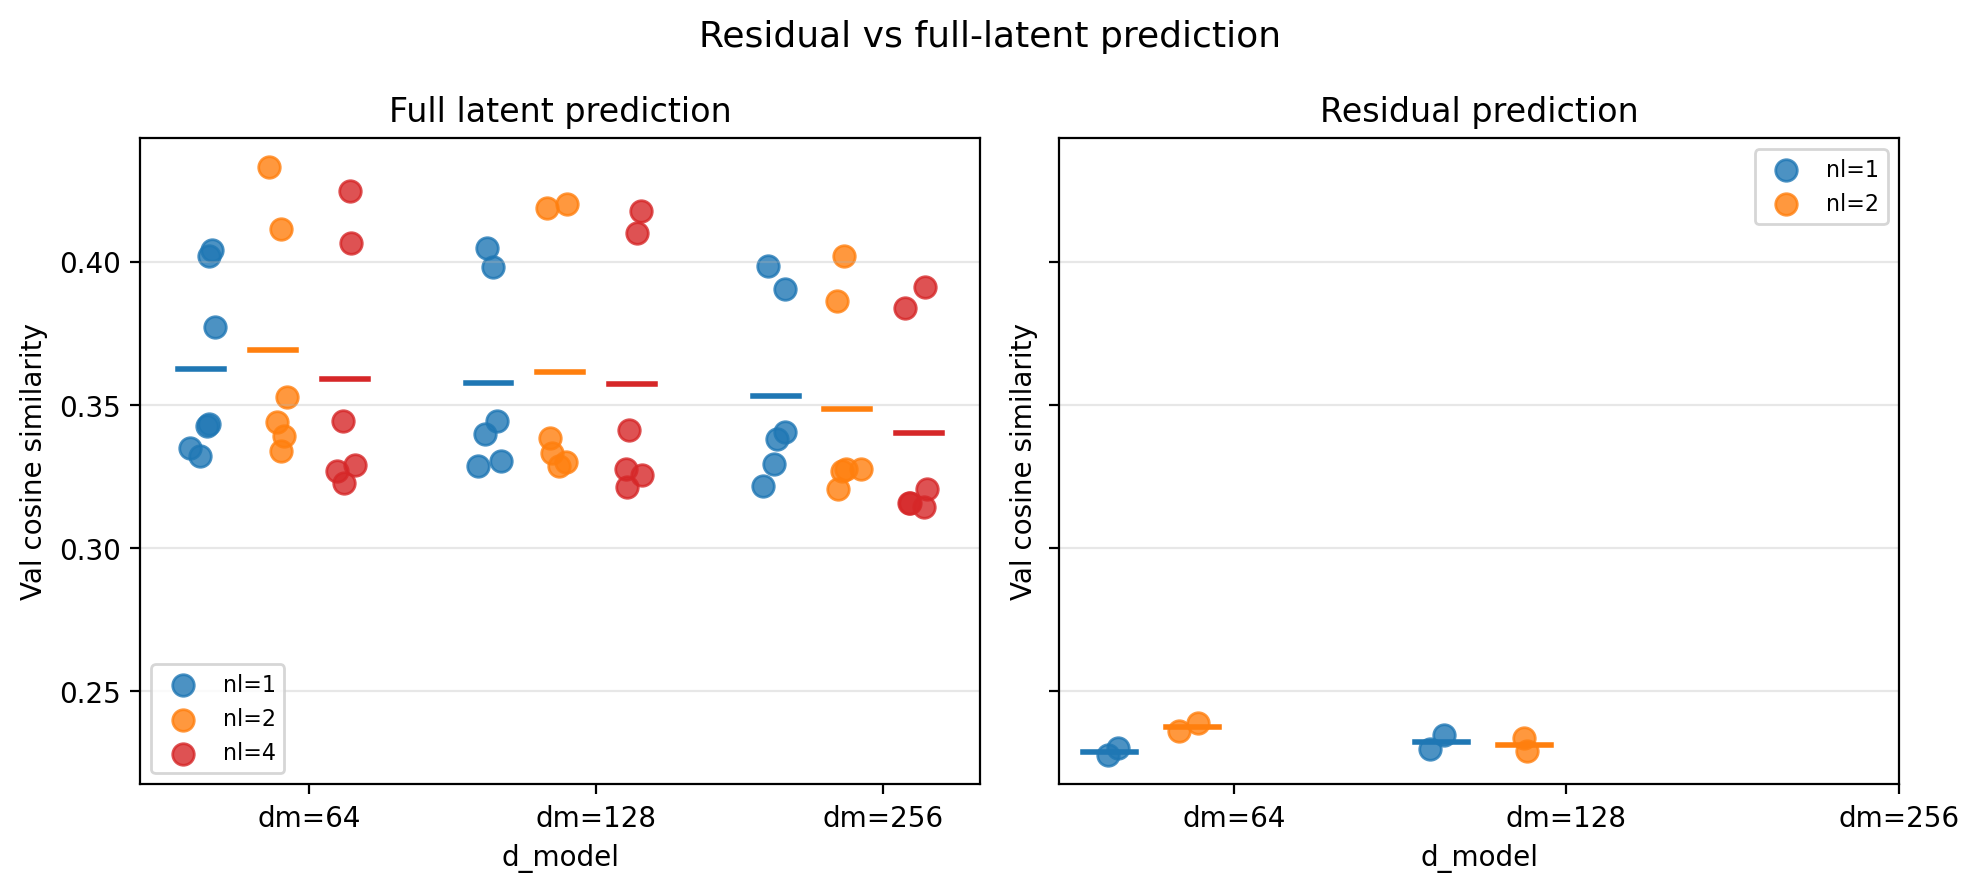

In [27]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

d_models     = sorted(df['d_model'].dropna().unique())
n_layers_all = sorted(df['n_layers'].dropna().unique())
palette      = plt.cm.tab10(np.linspace(0, 0.3, len(n_layers_all)))

for ax, res in zip(axes, [False, True]):
    sub = df[df['use_residual'] == res]
    for ci, nl in enumerate(n_layers_all):
        for di, dm in enumerate(d_models):
            grp = sub[(sub['n_layers'] == nl) & (sub['d_model'] == dm)]['val_cos_sim'].dropna().values
            if not len(grp):
                continue
            x = di + (ci - len(n_layers_all)/2) * 0.25
            jitter = rng.uniform(-0.05, 0.05, len(grp))
            ax.scatter(x + jitter, grp, color=palette[ci], s=60, alpha=0.8,
                       label=f'nl={int(nl)}' if di == 0 else '')
            ax.plot([x - 0.08, x + 0.08], [grp.mean(), grp.mean()], color=palette[ci], lw=2)
    ax.set_title('Residual prediction' if res else 'Full latent prediction')
    ax.set_xticks(range(len(d_models)))
    ax.set_xticklabels([f'dm={int(d)}' for d in d_models])
    ax.set_xlabel('d_model')
    ax.set_ylabel('Val cosine similarity')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Residual vs full-latent prediction', fontsize=13)
plt.tight_layout()
plt.show()

## Best run per condition

In [28]:
summary = (
    df.sort_values('val_cos_sim', ascending=False)
      .groupby(['use_residual', 'd_model', 'n_layers'], sort=False)
      .first()
      .reset_index()
)[['use_residual'] + [c for c in available if c != 'use_residual']]
display(summary)

,use_residual,d_model,n_layers,lr,epoch,train_loss,val_mse,val_cos_sim,test_mse,test_cos_sim
0,False,64,2,0.0003,27,20.184579,0.451946,0.432969,0.382713,0.346955
1,False,64,4,0.0003,26,20.017084,0.475135,0.424533,0.412275,0.342556
2,False,128,2,0.0010,12,20.271266,0.467333,0.420286,0.377301,0.371165
3,False,128,4,0.0003,21,17.982439,0.476487,0.417859,0.427427,0.323972
4,False,128,1,0.0003,23,18.533490,0.471092,0.404856,0.361717,0.371611
5,False,64,1,0.0003,26,21.938111,0.456384,0.404134,0.364402,0.332178
6,False,256,2,0.0003,19,16.123428,0.485370,0.402124,0.408547,0.368326
7,False,256,1,0.0003,17,19.952005,0.463978,0.398490,0.350979,0.396699
8,False,256,4,0.0010,7,23.210878,0.491788,0.391295,0.926210,0.296449
9,True,64,2,0.0010,33,0.520869,1.148815,0.238747,1.044944,0.178076


## LR sensitivity

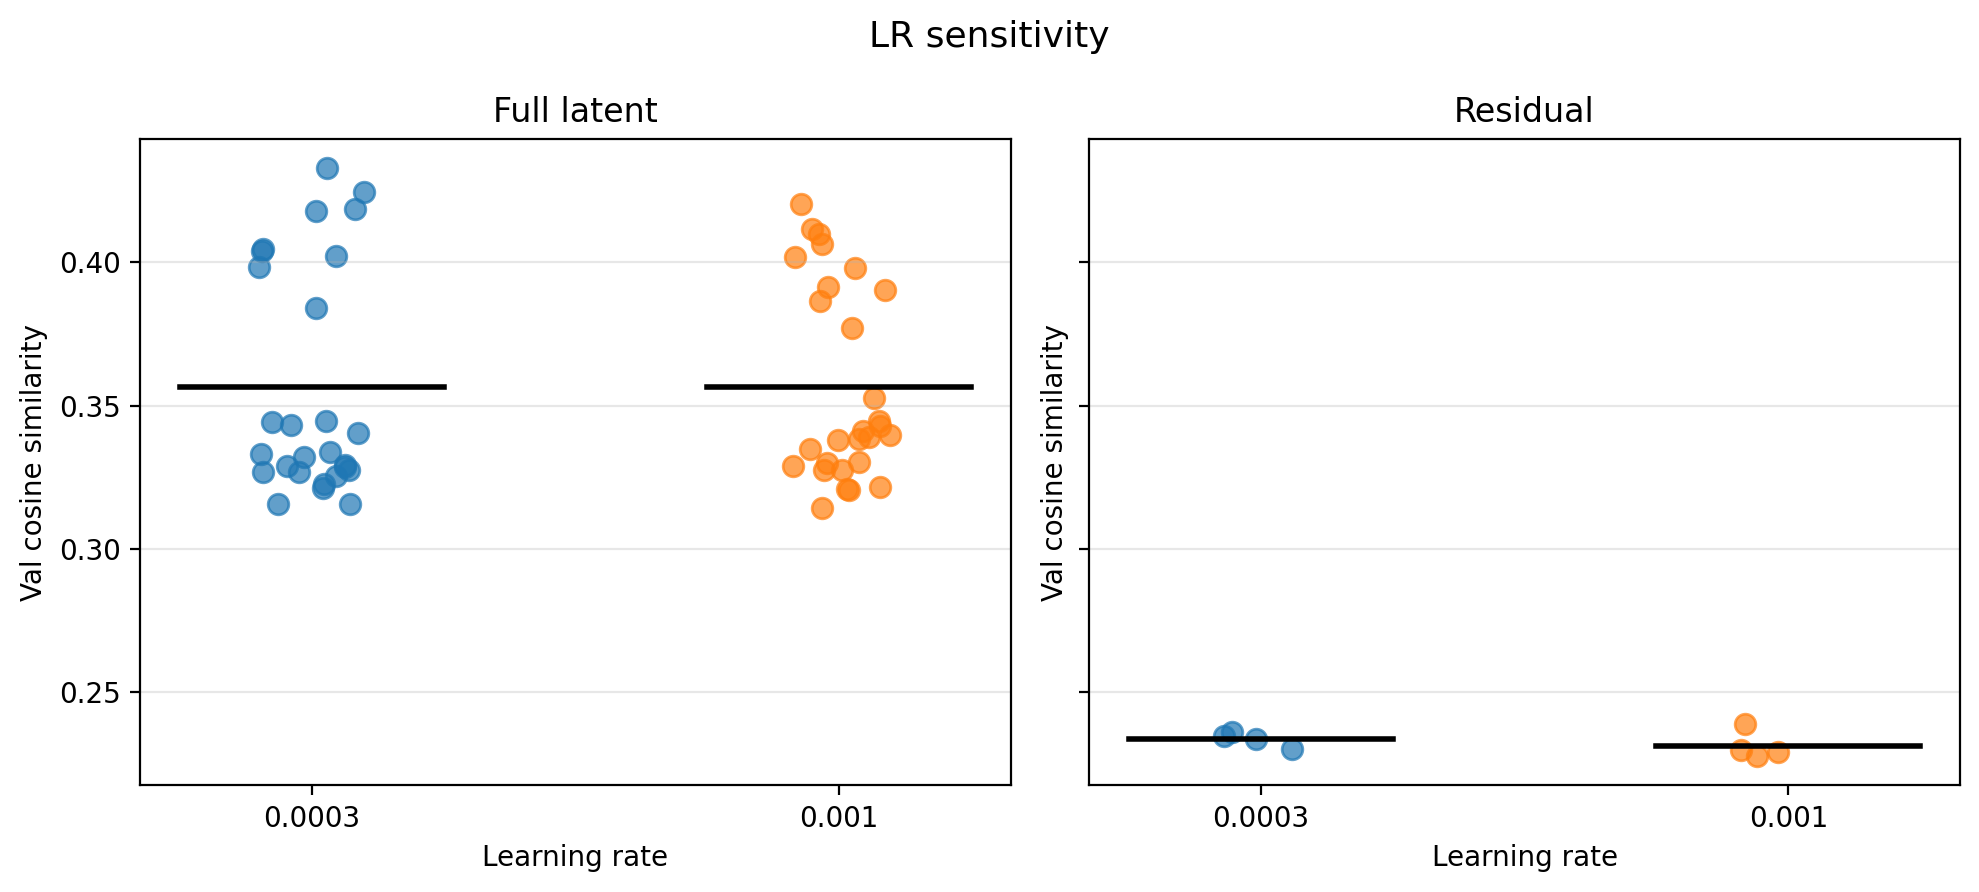

In [29]:
rng2 = np.random.default_rng(0)
lrs  = sorted(df['lr'].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, res in zip(axes, [False, True]):
    sub = df[df['use_residual'] == res]
    for i, lr in enumerate(lrs):
        grp = sub[sub['lr'] == lr]['val_cos_sim'].dropna().values
        jitter = rng2.uniform(-0.1, 0.1, len(grp))
        ax.scatter(i + jitter, grp, alpha=0.7, s=55)
        ax.plot([i - 0.25, i + 0.25], [grp.mean(), grp.mean()], color='black', lw=2)
    ax.set_xticks(range(len(lrs)))
    ax.set_xticklabels([str(lr) for lr in lrs])
    ax.set_xlabel('Learning rate')
    ax.set_ylabel('Val cosine similarity')
    ax.set_title('Residual' if res else 'Full latent')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('LR sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

---
# Object Recovery Test
Load the best residual and best full-latent checkpoints. Run inference on the **test set** (90 stimuli).  
Baselines:
- **Category mean** — no neural prediction, just use the training-split category average

MSE is in the original un-normalized latent space.

In [30]:
from train.train_canonical_latent import (
    load_canonical_latents, normalize_lat, to_pca, from_pca, compute_cat_means,
)
from train.train_latent import _load_hvm_neural, _hvm_stratified_split, prepare_input
from encoders import TemporalTransformer

best_res  = df[df['use_residual'] == True ].sort_values('val_cos_sim', ascending=False).iloc[0]
best_full = df[df['use_residual'] == False].sort_values('val_cos_sim', ascending=False).iloc[0]
print('Best residual run:   ', best_res['path'])
print('  val_cos=', best_res['val_cos_sim'], '  test_cos=', best_res['test_cos_sim'])
print('Best full-latent run:', best_full['path'])
print('  val_cos=', best_full['val_cos_sim'], '  test_cos=', best_full['test_cos_sim'])

Best residual run:    d64_nh4_nl2_c16_do0.1_lr0.001_wd0.01_bs32_cat_res_in0.05_nd0.1_nw0.1
  val_cos= 0.2387472540140152   test_cos= 0.17807644605636597
Best full-latent run: d64_nh4_nl2_c16_do0.1_lr0.0003_wd0.01_bs32_cat_pca64_in0.05_nd0.1_nw0.1
  val_cos= 0.4329691529273987   test_cos= 0.3469550907611847


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def load_run(row):
    ckpt = torch.load(row['ckpt_path'], weights_only=False, map_location='cpu')
    args_d = ckpt['args']
    neural_mean = ckpt['neural_mean'].to(device)
    neural_std  = ckpt['neural_std'].to(device)
    lat_mean    = ckpt['lat_mean'].to(device)
    lat_std     = ckpt['lat_std'].to(device)
    cat_means   = ckpt.get('cat_means')
    pca_comp    = ckpt.get('pca_components')
    pca_mean_v  = ckpt.get('pca_mean')
    lat_shape   = ckpt['lat_shape']
    out_dim     = args_d['pca_dim'] if args_d.get('pca_dim', 0) > 0 else int(np.prod(lat_shape))
    n_neurons   = neural_mean.shape[1]
    n_time      = neural_mean.shape[2]
    n_cat       = 10 if args_d.get('use_category') else 0
    model = TemporalTransformer(
        n_neurons=n_neurons, d_model=args_d['d_model'], n_heads=args_d['n_heads'],
        n_layers=args_d['n_layers'], out_dim=out_dim, dropout=0.0,
        n_categories=n_cat, normalize_output=False,
    ).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    return model, neural_mean, neural_std, lat_mean, lat_std, cat_means, pca_comp, pca_mean_v, args_d


def run_inference(row, neural_all, latents_all, cat_indices, test_idx):
    model, neural_mean, neural_std, lat_mean, lat_std, cat_means, pca_comp, pca_mean_v, args_d = load_run(row)
    use_res = args_d.get('use_residual', False)
    use_pca = pca_comp is not None
    use_cat = args_d.get('use_category', False)
    S = latents_all.shape[2]

    neural_test = neural_all[test_idx].to(device)
    lat_test    = latents_all[test_idx]
    cat_test    = cat_indices[test_idx].to(device)

    all_preds = []
    with torch.no_grad():
        for i in range(0, len(neural_test), 32):
            n_b  = (neural_test[i:i+32] - neural_mean) / neural_std
            x    = prepare_input(n_b, 'transformer')
            cat  = cat_test[i:i+32] if use_cat else None
            all_preds.append(model(x, cat).cpu())

    pred_flat = torch.cat(all_preds)
    if use_pca:
        pred_flat = from_pca(pred_flat, pca_comp, pca_mean_v)

    # un-whiten: pred is in whitened residual/latent space
    lat_mean_cpu = lat_mean.cpu()
    lat_std_cpu  = lat_std.cpu()
    pred_unwhite = pred_flat * lat_std_cpu.repeat_interleave(S*S) + lat_mean_cpu.repeat_interleave(S*S)
    pred_4d = pred_unwhite.reshape(-1, 16, S, S)

    # add category mean back for residual runs
    if use_res and cat_means is not None:
        pred_4d = pred_4d + cat_means[cat_indices[test_idx]]

    return pred_4d, lat_test


print('Functions ready.')

device: cuda
Functions ready.


In [32]:
# Load data once
rsp         = _load_hvm_neural()
neural_all  = torch.from_numpy(rsp).float()
latents_all = load_canonical_latents(16, 512)
cat_indices = torch.arange(HVM_N_STIMULI) // HVM_N_VAR

train_idx_np, val_idx_np, test_idx_np = _hvm_stratified_split(SEED)
train_idx = torch.from_numpy(train_idx_np).long()
test_idx  = torch.from_numpy(test_idx_np).long()

cat_means_baseline = compute_cat_means(latents_all, train_idx, cat_indices)

print(f'neural: {tuple(neural_all.shape)}  latents: {tuple(latents_all.shape)}  test: {len(test_idx)}')

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.52it/s]


neural: (450, 2330, 25)  latents: (450, 16, 16, 16)  test: 90


In [33]:
pred_res,  true_lat = run_inference(best_res,  neural_all, latents_all, cat_indices, test_idx)
pred_full, _        = run_inference(best_full, neural_all, latents_all, cat_indices, test_idx)
cat_mean_pred = cat_means_baseline[cat_indices[test_idx]]

def flat(x): return x.flatten(1)

cos_res     = F.cosine_similarity(flat(pred_res),      flat(true_lat), dim=-1)
cos_full    = F.cosine_similarity(flat(pred_full),     flat(true_lat), dim=-1)
cos_catmean = F.cosine_similarity(flat(cat_mean_pred), flat(true_lat), dim=-1)

mse_res     = ((pred_res     - true_lat)**2).mean(dim=(1,2,3))
mse_full    = ((pred_full    - true_lat)**2).mean(dim=(1,2,3))
mse_catmean = ((cat_mean_pred - true_lat)**2).mean(dim=(1,2,3))

print(f"{'Model':<26} {'cos_sim':>8}  {'MSE':>8}")
print('-' * 46)
print(f"{'Residual model':<26} {cos_res.mean():.4f}    {mse_res.mean():.4f}")
print(f"{'Full-latent model':<26} {cos_full.mean():.4f}    {mse_full.mean():.4f}")
print(f"{'Category mean (baseline)':<26} {cos_catmean.mean():.4f}    {mse_catmean.mean():.4f}")

/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model                       cos_sim       MSE
----------------------------------------------
Residual model             0.7576    0.5383
Full-latent model          0.7572    0.5389
Category mean (baseline)   0.7619    0.5343


## Per-stimulus cosine similarity distribution

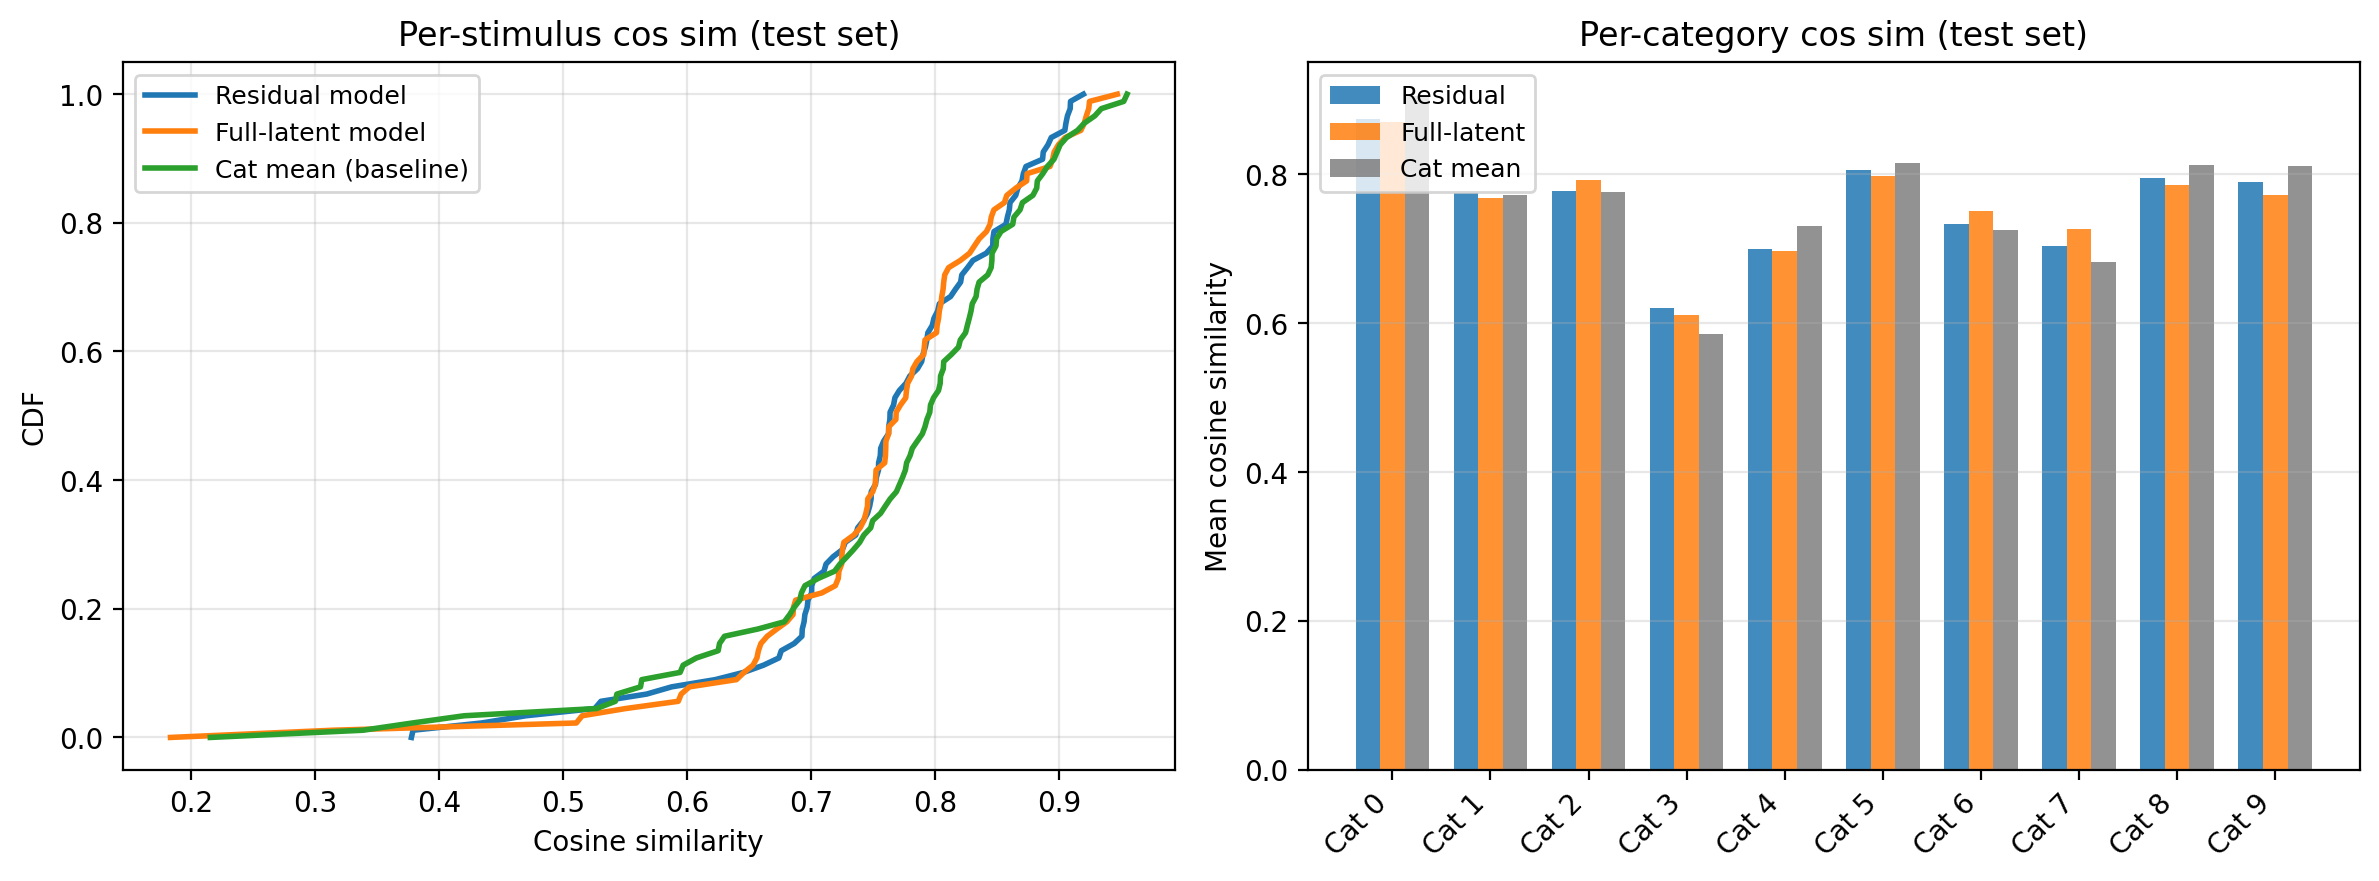

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# CDF
ax = axes[0]
for vals, label, color in [
    (cos_res,     'Residual model',      'tab:blue'),
    (cos_full,    'Full-latent model',   'tab:orange'),
    (cos_catmean, 'Cat mean (baseline)', 'tab:grey'),
]:
    sv = np.sort(vals.numpy())
    ax.plot(sv, np.linspace(0, 1, len(sv)), label=label, lw=2)
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('CDF')
ax.set_title('Per-stimulus cos sim (test set)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Per-category bar
ax = axes[1]
n_cats = 10
cat_labels = cat_indices[test_idx].numpy()
x = np.arange(n_cats)
w = 0.25
for offset, vals, label, color in [
    (-w, cos_res,     'Residual',    'tab:blue'),
    ( 0, cos_full,    'Full-latent', 'tab:orange'),
    ( w, cos_catmean, 'Cat mean',    'tab:grey'),
]:
    cat_cos = [vals[cat_labels == c].mean().item() for c in range(n_cats)]
    ax.bar(x + offset, cat_cos, width=w, label=label, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Cat {c}' for c in range(n_cats)], rotation=45, ha='right')
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Per-category cos sim (test set)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Within-category variation recovery
Remove the category mean from both prediction and ground truth — how well does each model capture within-category variation?

Within-category residual recovery (test set):
  Residual model:    cos=0.1967   R²=-0.0076
  Full-latent model: cos=0.2267   R²=-0.0086


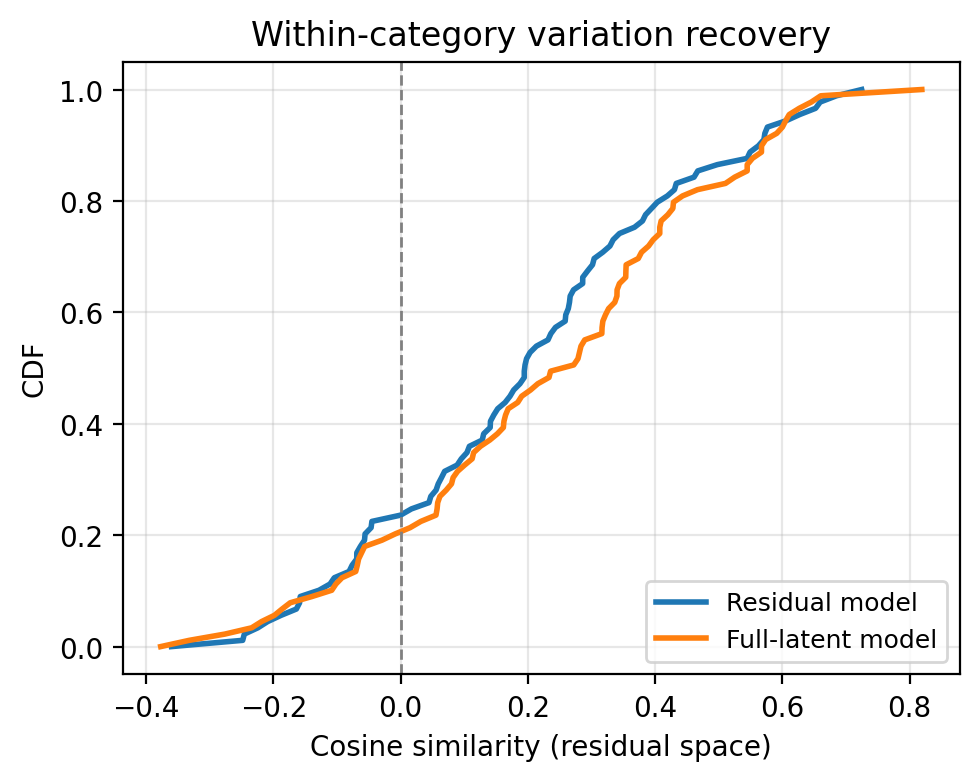

In [35]:
true_resid      = true_lat    - cat_mean_pred
pred_res_resid  = pred_res    - cat_mean_pred
pred_full_resid = pred_full   - cat_mean_pred

cos_res_resid   = F.cosine_similarity(flat(pred_res_resid),  flat(true_resid), dim=-1)
cos_full_resid  = F.cosine_similarity(flat(pred_full_resid), flat(true_resid), dim=-1)

var_res  = 1 - ((pred_res_resid  - true_resid)**2).mean() / true_resid.var()
var_full = 1 - ((pred_full_resid - true_resid)**2).mean() / true_resid.var()

print('Within-category residual recovery (test set):')
print(f'  Residual model:    cos={cos_res_resid.mean():.4f}   R²={var_res:.4f}')
print(f'  Full-latent model: cos={cos_full_resid.mean():.4f}   R²={var_full:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
for vals, label, color in [
    (cos_res_resid,  'Residual model',    'tab:blue'),
    (cos_full_resid, 'Full-latent model', 'tab:orange'),
]:
    sv = np.sort(vals.numpy())
    ax.plot(sv, np.linspace(0, 1, len(sv)), label=label, color=color, lw=2)
ax.axvline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('Cosine similarity (residual space)')
ax.set_ylabel('CDF')
ax.set_title('Within-category variation recovery')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Latent patch visualization
First 4 VAE channels of True | Residual pred | Full-latent pred for a sample of test stimuli.

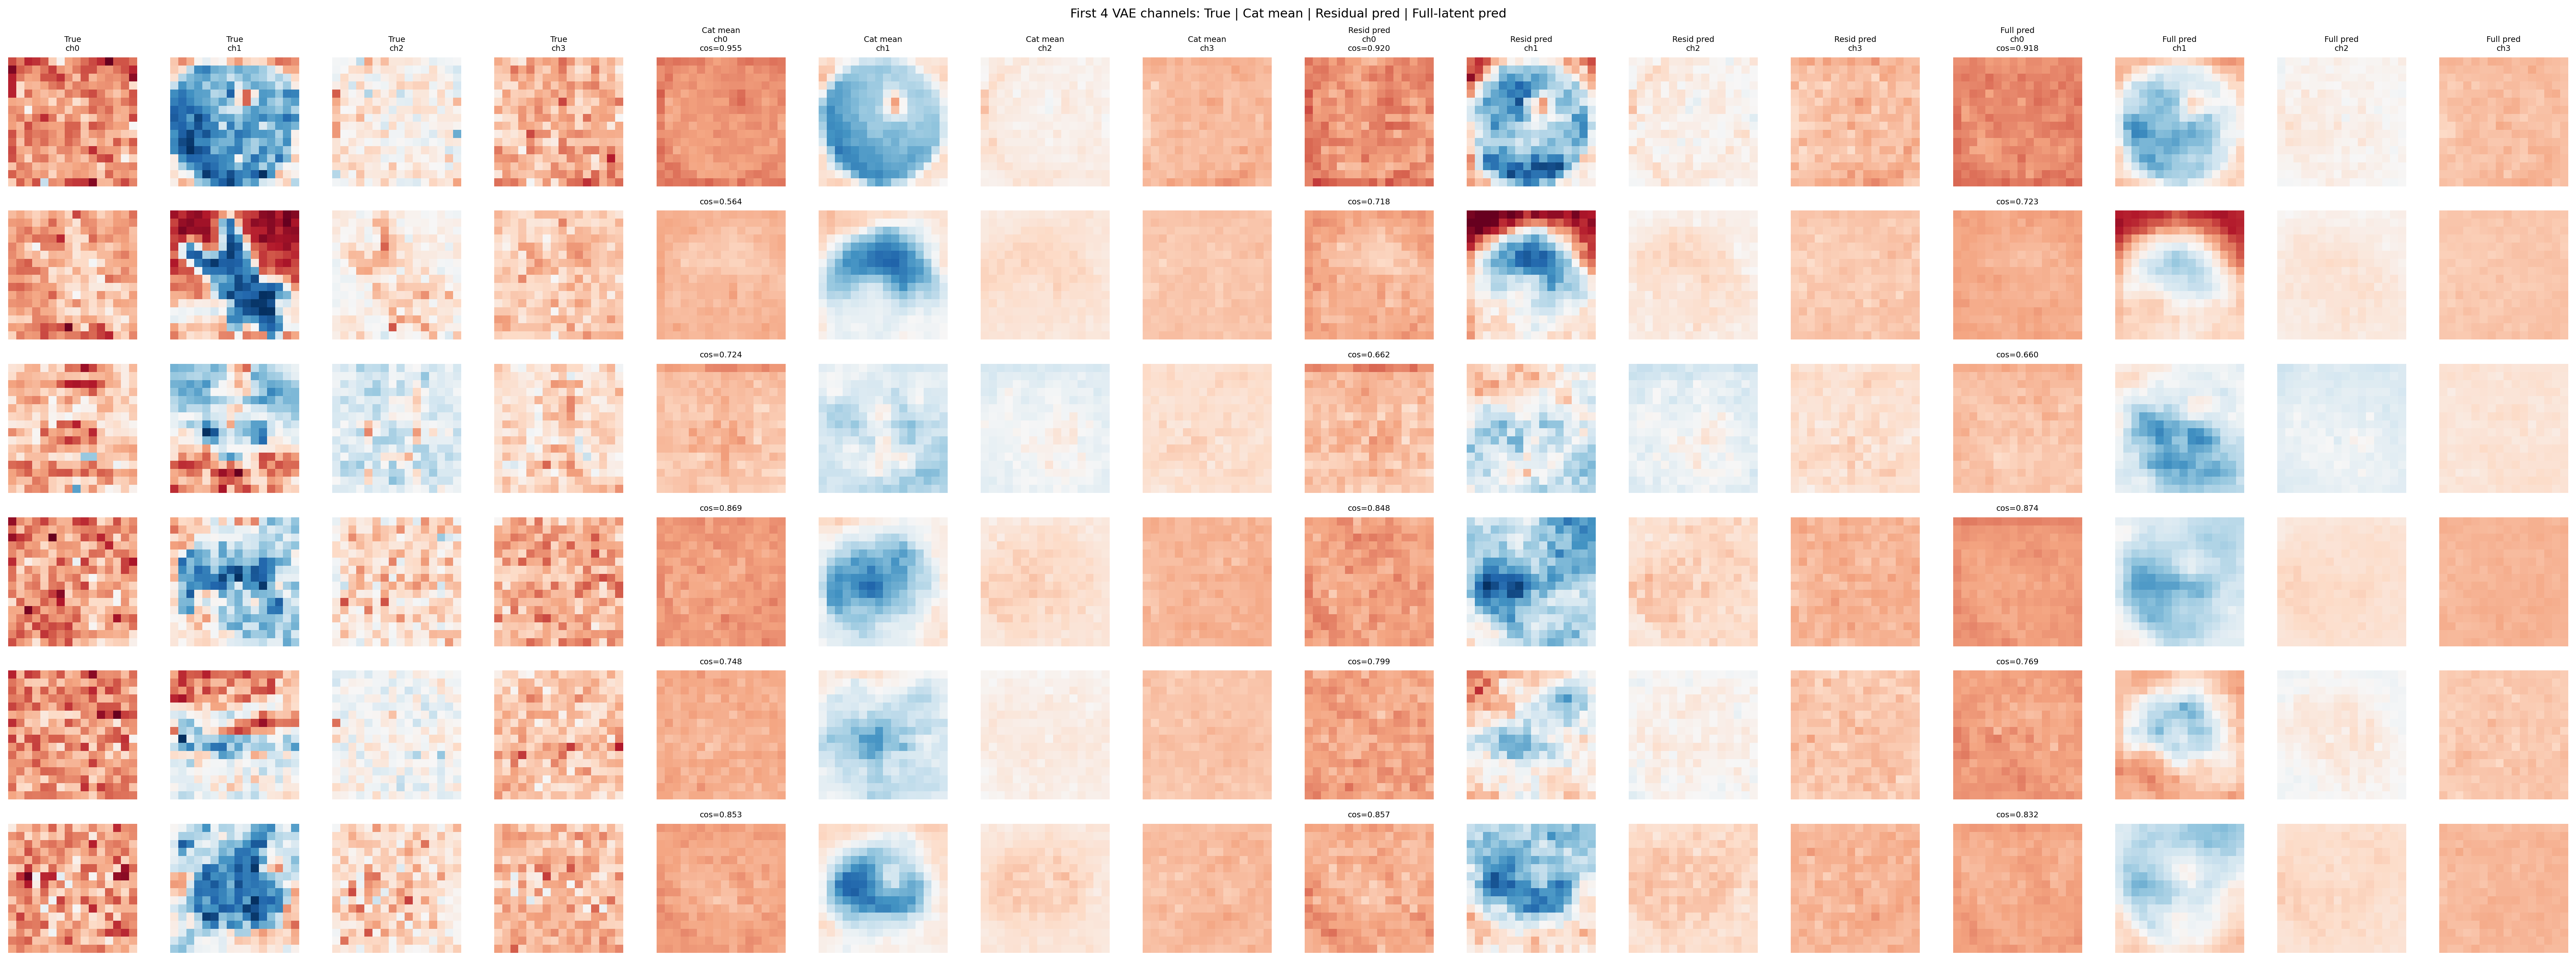

In [38]:
N_SHOW  = 6
N_CHAN  = 4
indices = np.linspace(0, len(test_idx)-1, N_SHOW, dtype=int)

panels = [
    ('True',        true_lat,        None),
    ('Cat mean',    cat_mean_pred,   cos_catmean),
    ('Resid pred',  pred_res,        cos_res),
    ('Full pred',   pred_full,       cos_full),
]

fig, axes = plt.subplots(N_SHOW, N_CHAN * len(panels),
                         figsize=(N_CHAN * len(panels) * 2, N_SHOW * 2))

for row_i, stim_i in enumerate(indices):
    vmin = true_lat[stim_i, :N_CHAN].min().item()
    vmax = true_lat[stim_i, :N_CHAN].max().item()
    for p_i, (title, data, cos_vals) in enumerate(panels):
        col_off = p_i * N_CHAN
        for ch in range(N_CHAN):
            ax = axes[row_i, col_off + ch]
            ax.imshow(data[stim_i, ch].numpy(), vmin=vmin, vmax=vmax, cmap='RdBu_r', aspect='equal')
            ax.axis('off')
            if row_i == 0:
                ax.set_title(f'{title}\nch{ch}', fontsize=7)
        if cos_vals is not None:
            c_val = cos_vals[stim_i].item()
            ax0 = axes[row_i, col_off]
            lbl = f'cos={c_val:.3f}'
            ax0.set_title(ax0.get_title() + f'\n{lbl}' if row_i == 0 else lbl, fontsize=7)
    cat_label = cat_indices[test_idx[stim_i]].item()
    axes[row_i, 0].set_ylabel(f'Cat {cat_label} #{stim_i}', fontsize=7)

fig.suptitle('First 4 VAE channels: True | Cat mean | Residual pred | Full-latent pred', fontsize=11)
plt.tight_layout()
plt.show()

## Save best config

In [37]:
import json

best = df.sort_values('val_cos_sim', ascending=False).iloc[0]
ckpt_best = torch.load(best['ckpt_path'], weights_only=False, map_location='cpu')
args_best = ckpt_best['args']

cfg = {
    'dataset':       'hvm',
    'target':        'canonical_latent',
    'model':         'transformer',
    'use_residual':  bool(best['use_residual']),
    'use_category':  args_best.get('use_category', True),
    'canonical_lat': args_best.get('canonical_lat', 16),
    'val_cos_sim':   float(best['val_cos_sim']),
    'val_mse':       float(best['val_mse']) if pd.notna(best.get('val_mse')) else None,
    'test_cos_sim':  float(best['test_cos_sim']) if pd.notna(best['test_cos_sim']) else None,
    'test_mse':      float(best['test_mse']) if pd.notna(best['test_mse']) else None,
    'd_model':       int(best['d_model']),
    'n_heads':       args_best.get('n_heads', 4),
    'n_layers':      int(best['n_layers']),
    'lr':            float(best['lr']),
    'weight_decay':  args_best.get('weight_decay', 1e-2),
    'checkpoint':    best['ckpt_path'],
}
out_path = CACHE_DIR / 'best_canonical_latent_config.json'
out_path.write_text(json.dumps(cfg, indent=2))
print(f'Saved to {out_path}')
print(json.dumps(cfg, indent=2))

Saved to /home/yy3658/NeurObjectGen/cache/best_canonical_latent_config.json
{
  "dataset": "hvm",
  "target": "canonical_latent",
  "model": "transformer",
  "use_residual": false,
  "use_category": true,
  "canonical_lat": 16,
  "val_cos_sim": 0.4329691529273987,
  "val_mse": 0.45194607973098755,
  "test_cos_sim": 0.3469550907611847,
  "test_mse": 0.3827129304409027,
  "d_model": 64,
  "n_heads": 4,
  "n_layers": 2,
  "lr": 0.0003,
  "weight_decay": 0.01,
  "checkpoint": "/home/yy3658/NeurObjectGen/checkpoints/hvm/transformer/canonical_latent/d64_nh4_nl2_c16_do0.1_lr0.0003_wd0.01_bs32_cat_pca64_in0.05_nd0.1_nw0.1/best.pt"
}
